In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.sparse import diags, kron, eye as speye
from scipy.sparse.linalg import spsolve

plt.rcParams["figure.figsize"] = (8, 4.5)

# Задание 1

Дана разностная схема для уравнения переноса $u_t + a u_x = f(t,x)$, $u(0,x) = \varphi(x)$:

$$
\frac{y_k^{n+1} - y_k^n}{\tau}
+ \frac{a}{2}\left[\frac{y_{k+1}^{n+1} - y_{k-1}^{n+1}}{2h}
+ \frac{y_{k+1}^{n} - y_{k-1}^{n}}{2h}\right]
= \frac{1}{2}(f_k^{n+1} + f_k^n)
$$


### Аппроксимация

Разложим в ряд Тейлора в точке $(x_k, t^{n+1/2})$.

Временная производная: $\frac{u_k^{n+1} - u_k^n}{\tau} = u_t\big|_{t^{n+1/2}} + \frac{\tau^2}{24} u_{ttt} + O(\tau^4)$.

Пространственная производная на слое $t^n$: $\frac{u_{k+1}^n - u_{k-1}^n}{2h} = u_x\big|_{t^n} + \frac{h^2}{6} u_{xxx} + O(h^4)$. Аналогично на слое $t^{n+1}$.

Их среднее: $\frac{1}{2}\bigl(u_x\big|_{t^n} + u_x\big|_{t^{n+1}}\bigr) = u_x\big|_{t^{n+1/2}} + O(\tau^2)$.

Правая часть: $\frac{1}{2}(f^{n+1} + f^n) = f\big|_{t^{n+1/2}} + O(\tau^2)$.

Итого невязка: $\psi = O(\tau^2 + h^2)$. Схема имеет второй порядок аппроксимации по $\tau$ и $h$.

### Устойчивость

Подставим $y_k^n = \lambda^n e^{i\alpha k h}$ при $f = 0$:

$$
\frac{\lambda - 1}{\tau} + \frac{a}{2} \cdot \frac{i\sin(\alpha h)}{h}(\lambda + 1) = 0
$$

Обозначим $\sigma = \frac{a\tau}{2h}$. Тогда:

$$
\lambda = \frac{1 - i\sigma\sin(\alpha h)}{1 + i\sigma\sin(\alpha h)} \Rightarrow |\lambda|^2 = \frac{1 + \sigma^2\sin^2(\alpha h)}{1 + \sigma^2\sin^2(\alpha h)} = 1
$$

Это верно $\forall \tau \text{ и } h>0$, т.е. схема безусловно устойчива

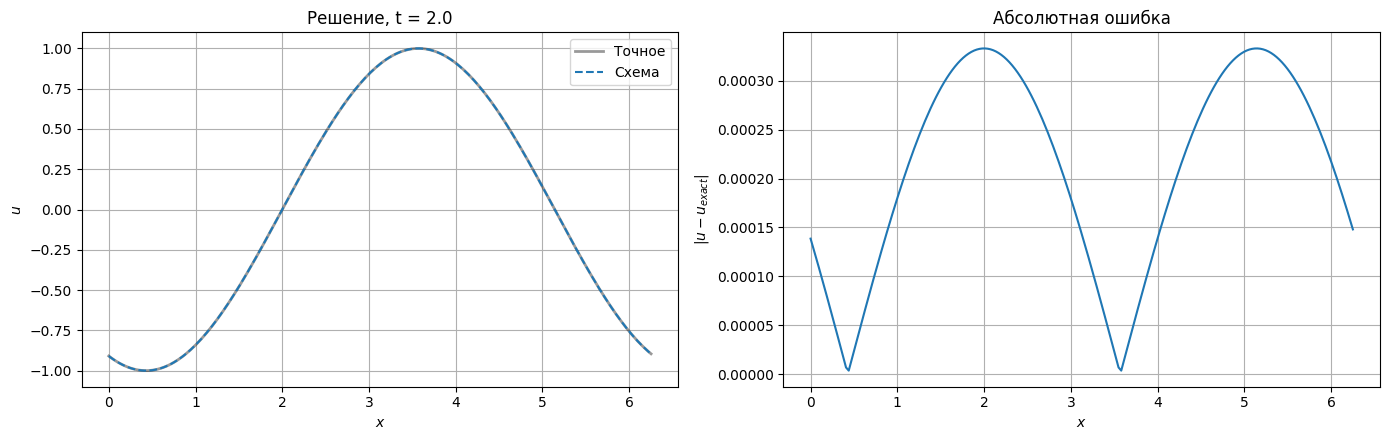

max |u - u_exact| = 3.3312e-04


In [12]:
a = 1.0
L = 2 * np.pi
T1 = 2.0
Nx1 = 200
Nt1 = 400
h1 = L / Nx1
tau1 = T1 / Nt1
r1 = a * tau1 / (4 * h1)

x1 = np.linspace(0, L, Nx1, endpoint=False)
u1 = np.sin(x1).copy()

A1 = np.eye(Nx1)
B1 = np.eye(Nx1)
for k in range(Nx1):
    kp = (k + 1) % Nx1
    km = (k - 1) % Nx1
    A1[k, kp] += r1
    A1[k, km] -= r1
    B1[k, kp] -= r1
    B1[k, km] += r1

for n in range(Nt1):
    u1 = np.linalg.solve(A1, B1 @ u1)

u1_exact = np.sin(x1 - a * T1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(x1, u1_exact, "k-", lw=2, alpha=0.4, label="Точное")
axes[0].plot(x1, u1, "--", label="Схема")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$u$")
axes[0].set_title(f"Решение, t = {T1}")
axes[0].legend()
axes[0].grid()

axes[1].plot(x1, np.abs(u1 - u1_exact))
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$|u - u_{exact}|$")
axes[1].set_title("Абсолютная ошибка")
axes[1].grid()

plt.tight_layout()
plt.show()

print(f"max |u - u_exact| = {np.max(np.abs(u1 - u1_exact)):.4e}")

# Задание 2

Для уравнения $u_t = a^2(x,t)\, u_{xx}$, $u(x,0) = \psi(x)$ построим две разностные схемы с разными шаблонами.

### 1: Явная разностная схема

Шаблон: $(k, n),\; (k\pm1, n),\; (k, n+1)$

$$
\frac{y_k^{n+1} - y_k^n}{\tau} = a^2 \frac{y_{k+1}^n - 2y_k^n + y_{k-1}^n}{h^2}
$$


По принципу замороженных коэффициентов полагаем $a^2 = \text{const}$ и подставляем гармонику $y_k^n = \lambda^n e^{i\alpha k h}$:

$$
\frac{\lambda^{n+1} e^{i\alpha kh} - \lambda^n e^{i\alpha kh}}{\tau}
= a^2 \frac{\lambda^n e^{i\alpha(k+1)h} - 2\lambda^n e^{i\alpha kh} + \lambda^n e^{i\alpha(k-1)h}}{h^2}
$$

Сократим на $\lambda^n e^{i\alpha kh}$:

$$
\frac{\lambda - 1}{\tau} = \frac{a^2}{h^2}\bigl(e^{i\alpha h} - 2 + e^{-i\alpha h}\bigr)
$$

Используем $e^{i\alpha h} + e^{-i\alpha h} = 2\cos(\alpha h) = 2 - 4\sin^2(\alpha h/2)$:

$$
\frac{\lambda - 1}{\tau} = \frac{a^2}{h^2}\bigl(-4\sin^2(\alpha h/2)\bigr)
$$

Обозначим $s = a^2\tau/h^2$. Тогда:

$$
\lambda = 1 - 4s\sin^2\!\left(\frac{\alpha h}{2}\right)
$$

При $\sin^2(\alpha h/2) = 1$ имеем $\lambda_{\min} = 1 - 4s$. Условие $|\lambda| \le 1$ требует $1 - 4s \ge -1$, т.е. $s \le 1/2$.

Таким образом схема условно устойчива, с условием $\tau \le h^2/(2a^2_{\max})$.

### 2: Схема Кранка-Никольсон

Шаблон: $(k, n),\; (k\pm1, n),\; (k, n+1),\; (k\pm1, n+1)$

$$
\frac{y_k^{n+1} - y_k^n}{\tau} = \frac{a^2}{2}\left[\frac{y_{k+1}^{n+1} - 2y_k^{n+1} + y_{k-1}^{n+1}}{h^2} + \frac{y_{k+1}^n - 2y_k^n + y_{k-1}^n}{h^2}\right]
$$

Подставляем $y_k^n = \lambda^n e^{i\alpha kh}$ и сокращаем на $\lambda^n e^{i\alpha kh}$:

$$
\frac{\lambda - 1}{\tau} = \frac{a^2}{2h^2}\bigl(e^{i\alpha h} - 2 + e^{-i\alpha h}\bigr)(\lambda + 1)
$$

Обозначим $\mu = e^{i\alpha h} - 2 + e^{-i\alpha h} = -4\sin^2(\alpha h/2)$. Тогда:

$$
\lambda - 1 = \frac{s}{2}\,\mu\,(\lambda + 1)
$$

где $s = a^2\tau/h^2$. Пусть $\xi = -s\mu/2 = 2s\sin^2(\alpha h/2) \ge 0$. Тогда:

$$
\lambda - 1 = -\xi(\lambda + 1) \;\;\Longrightarrow\;\; \lambda(1 + \xi) = 1 - \xi
$$

$$
\lambda = \frac{1 - \xi}{1 + \xi} = \frac{1 - 2s\sin^2(\alpha h/2)}{1 + 2s\sin^2(\alpha h/2)}
$$

Так как $\xi \ge 0$, имеем $|1 - \xi| \le 1 + \xi$, откуда $|\lambda| \le 1$ при любом $s \ge 0$, т.е. схема безусловно устойчива

# Задание 3

### Найдем точное решение

Будем искать решение в виде $u(x,y,t) = A(t)\sin(\pi x)\sin(\pi y)$.

Вычислим: $u_t = A'\sin\pi x\sin\pi y$, $u_{xx} = -\pi^2 A\sin\pi x\sin\pi y$, $u_{yy} = -\pi^2 A\sin\pi x\sin\pi y$.

Подставим в $u_t = u_{xx} + u_{yy} + f$ и сократим на $\sin\pi x\sin\pi y$:

$$A'(t) = -2\pi^2 A(t) + 2\pi^2 \Rightarrow A(t) = 1 + Ce^{-2\pi^2 t}$$

Из $A(0) = 0$ получаем $C = -1$.

Итого: $u(x,y,t) = (1 - e^{-2\pi^2 t})\sin(\pi x)\sin(\pi y)$.

(В условии задачи указано $e^{-\pi^2 t}$, но я у себя ошибку не нашел, так что видимо опечатка)

### Схема переменных направлений

Обозначим $r = \tau/(2h^2)$. Каждый временной шаг разбивается на два полушага.

Полушаг 1, неявный по $x$, явный по $y$ -  для каждого фиксированного $j$ решаем СЛАУ по $i$:

$$
-r\, u^*_{i-1,j} + (1+2r)\, u^*_{i,j} - r\, u^*_{i+1,j}
= r\, u^n_{i,j-1} + (1-2r)\, u^n_{i,j} + r\, u^n_{i,j+1} + \tfrac{\tau}{2} f_{i,j}
$$

Полушаг 2 (явный по $x$, неявный по $y$) - для каждого фиксированного $i$ решаем СЛАУ по $j$:

$$
-r\, u^{n+1}_{i,j-1} + (1+2r)\, u^{n+1}_{i,j} - r\, u^{n+1}_{i,j+1}
= r\, u^*_{i-1,j} + (1-2r)\, u^*_{i,j} + r\, u^*_{i+1,j} + \tfrac{\tau}{2} f_{i,j}
$$

Обе СЛАУ трёхдиагональные, а значит будем решать их прогонкой. Итоговый порядок аппроксимации: $O(\tau^2 + h^2)$.

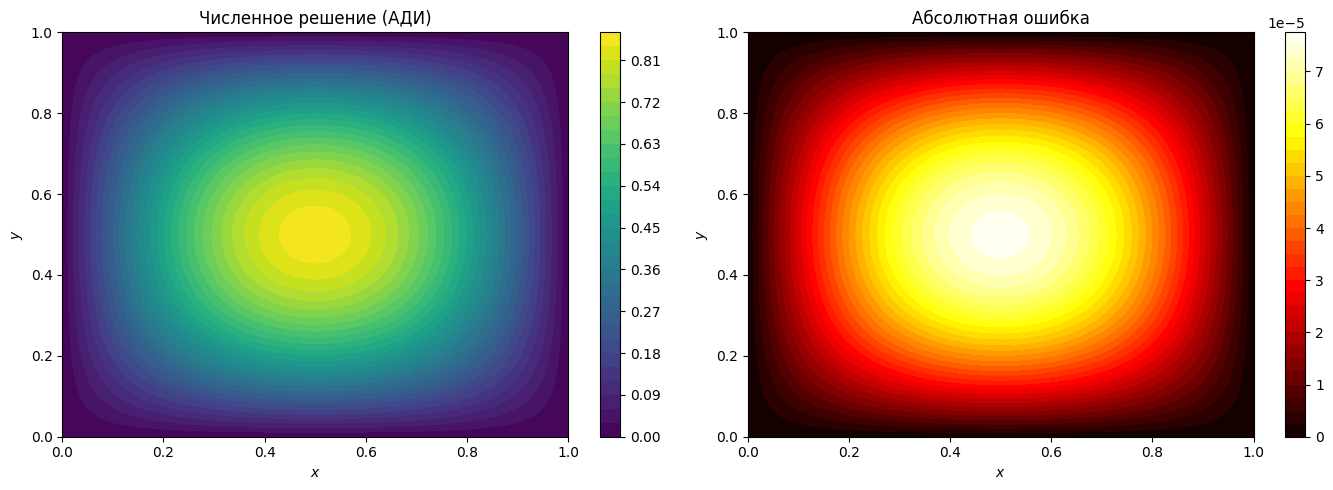

In [13]:
def solve_adi(N, Nt, T_final):
    h = 1.0 / N
    tau = T_final / Nt
    r = tau / (2 * h**2)

    x = np.linspace(0, 1, N + 1)
    y = np.linspace(0, 1, N + 1)
    X, Y = np.meshgrid(x, y, indexing="ij")

    f_val = 2 * np.pi**2 * np.sin(np.pi * X) * np.sin(np.pi * Y)
    u = np.zeros((N + 1, N + 1))

    Ni = N - 1
    ab = np.zeros((3, Ni))
    ab[0, 1:] = -r
    ab[1, :] = 1 + 2 * r
    ab[2, :-1] = -r

    for _ in range(Nt):
        u_star = np.zeros_like(u)
        for j in range(1, N):
            rhs = (r * u[1:N, j - 1]
                   + (1 - 2 * r) * u[1:N, j]
                   + r * u[1:N, j + 1]
                   + tau / 2 * f_val[1:N, j])
            u_star[1:N, j] = solve_banded((1, 1), ab, rhs)

        u_new = np.zeros_like(u)
        for i in range(1, N):
            rhs = (r * u_star[i - 1, 1:N]
                   + (1 - 2 * r) * u_star[i, 1:N]
                   + r * u_star[i + 1, 1:N]
                   + tau / 2 * f_val[i, 1:N])
            u_new[i, 1:N] = solve_banded((1, 1), ab, rhs)

        u = u_new

    u_exact = (1 - np.exp(-2 * np.pi**2 * T_final)) * np.sin(np.pi * X) * np.sin(np.pi * Y)
    return X, Y, u, u_exact


T3 = 0.1
Ns3 = [10, 20, 40, 80]
errs3 = []
for N in Ns3:
    Nt = 2 * N
    X3, Y3, u3, u3_ex = solve_adi(N, Nt, T3)
    err = np.max(np.abs(u3 - u3_ex))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c1 = axes[0].contourf(X3, Y3, u3, levels=30, cmap="viridis")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel("$y$")
axes[0].set_title("Численное решение (АДИ)")
plt.colorbar(c1, ax=axes[0])

c2 = axes[1].contourf(X3, Y3, np.abs(u3 - u3_ex), levels=30, cmap="hot")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$y$")
axes[1].set_title("Абсолютная ошибка")
plt.colorbar(c2, ax=axes[1])

plt.tight_layout()
plt.show()

# Задание 4

Решаем нелинейное эллиптическое уравнение:

$$
\frac{\partial}{\partial x}\!\left(u\,\frac{\partial u}{\partial x}\right) + \frac{\partial}{\partial y}\!\left(u\,\frac{\partial u}{\partial y}\right) = 0
$$

на $[0, X] \times [0, Y]$ с ГУ: $u(0,y)=1$, $u(x,Y)=1+x^2$, $u(X,y)=1+X^2 y/Y$, $u(x,0)=1$.

Раскроем уравнение: $u_x^2 + u\,u_{xx} + u_y^2 + u\,u_{yy} = 0$. Явно видно что оно нелинейно

Более того, заметим, что: $\frac{\partial}{\partial x}(u\,u_x) = \frac{1}{2}\frac{\partial^2(u^2)}{\partial x^2}$.

Тогда подставновка $v = u^2$ сводит уравнение к $\nabla^2 v = 0$ (при $u > 0$).

Граничные условия на $v$: $v(0,y)=1$, $v(x,Y)=(1+x^2)^2$, $v(X,y)=(1+X^2 y/Y)^2$, $v(x,0)=1$.

Решив, находим $u = \sqrt{v}$.

### Разностная схема

Переход к Лапласу позволяет нам строить разностную схему для $\nabla^2 v = 0$:

$$
\frac{v_{i-1,j} - 2v_{i,j} + v_{i+1,j}}{h_x^2} + \frac{v_{i,j-1} - 2v_{i,j} + v_{i,j+1}}{h_y^2} = 0
$$

Возьмем $h_x = h_y = h$ и получим:

$$
v_{i-1,j} + v_{i+1,j} + v_{i,j-1} + v_{i,j+1} - 4v_{i,j} = 0
$$

С порядком аппроксимации аппроксимации: $O(h_x^2 + h_y^2)$.

Такая система уже линейная, так что будем собирать  $2D$-лапласиан как кронекерово произведение одномерных операторов и решать прямым методом

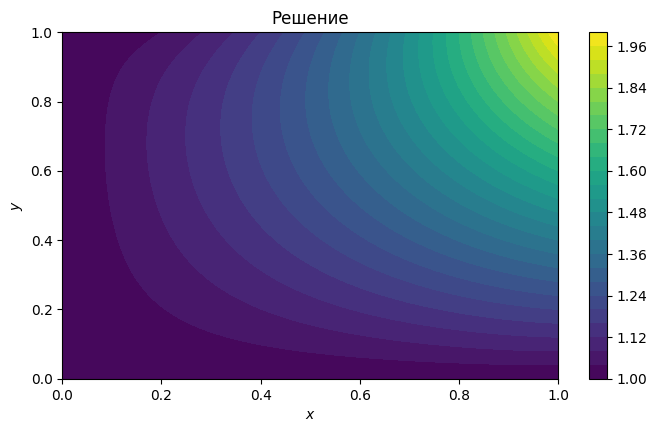

In [14]:
X_dom, Y_dom = 1.0, 1.0
N4 = 80
hx4 = X_dom / N4
hy4 = Y_dom / N4
x4 = np.linspace(0, X_dom, N4 + 1)
y4 = np.linspace(0, Y_dom, N4 + 1)

Ni4 = N4 - 1
e1 = np.ones(Ni4)

Lx = diags([e1[1:], -2 * e1, e1[1:]], [-1, 0, 1], shape=(Ni4, Ni4)) / hx4**2
Ly = diags([e1[1:], -2 * e1, e1[1:]], [-1, 0, 1], shape=(Ni4, Ni4)) / hy4**2
Ix = speye(Ni4)
Iy = speye(Ni4)

L2d = kron(Iy, Lx) + kron(Ly, Ix)

rhs4 = np.zeros((Ni4, Ni4))
for ii in range(Ni4):
    i = ii + 1
    for jj in range(Ni4):
        j = jj + 1
        v_left = 1.0 if i == 1 else 0.0
        v_right = (1 + X_dom**2 * y4[j] / Y_dom)**2 if i == N4 - 1 else 0.0
        v_bottom = 1.0 if j == 1 else 0.0
        v_top = (1 + x4[i]**2)**2 if j == N4 - 1 else 0.0
        rhs4[ii, jj] = -(v_left / hx4**2 + v_right / hx4**2
                         + v_bottom / hy4**2 + v_top / hy4**2)

v_int = spsolve(L2d, rhs4.ravel())
v_full = np.ones((N4 + 1, N4 + 1))
for j in range(N4 + 1):
    v_full[0, j] = 1.0
    v_full[N4, j] = (1 + X_dom**2 * y4[j] / Y_dom)**2
for i in range(N4 + 1):
    v_full[i, 0] = 1.0
    v_full[i, N4] = (1 + x4[i]**2)**2
v_full[1:N4, 1:N4] = v_int.reshape((Ni4, Ni4))
u4 = np.sqrt(np.maximum(v_full, 0.0))

X4, Y4 = np.meshgrid(x4, y4, indexing="ij")

fig, ax = plt.subplots()
c = ax.contourf(X4, Y4, u4, levels=30, cmap="viridis")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Решение")
plt.colorbar(c, ax=ax)
plt.show()